# 1. generate circle data
- `np.random.seed()` mengatur global random generator numpy, biar semua fungsi numpy yg random jadi reproducible. jadi ini bakal ngaruh ke `center_points = np.random.normal()` dkk.
- `random_state=` pada make_circles ini khusus untuk fungsi dari sklearn, dia punya random generator tersendiri dan tidak tergantung numpy global. jadi ini ngaruh ke make_circles.
- `make_circles()`. X numpy array shape (200,2 --> fitur (x1,x2). y numpy array shape (200,2) --> label (0 atau 1). `n_samples` jumlah data points. `factor` mengatur radius lingkaran dalam. lingkaran luar radiusnya ≈1, lingkaran dalam radiusnya ≈ factor. factor kecil, inner circle makin kecil. factor besar, inner circle makin dekat ke outer. `noise` cara kerjanya adalah setiap titik digeser dengan gaussian noise. noise ~ N(0, 0.05), distribusi normal.

## add healthy center points
- awalnya 2 concentric circles. lalu, ditambah titik lagi di tengah, dengan jumlah 100 titik.
- `np.random.normal()`, parameter: `loc` mean (pusat distribusi). `scale` standar deviasi. `size(100,2)` 100 titik, masing2 2D.
- interpretasi: semua center points digenerate di sekitar (0,0), tersebar dengan lebar ≈ 0.2.
- `center_labels = np.ones(n_center)` --> label +1

## combine dataset
- X vertikal: X(200,2), center_points(100,2) ---> (300,2)
- y horizontal: y(200,), center_labels(100,) ---> (300,)

---
`label='Healthy' if label_val == 1 else 'Risky'`  
1 = healthy  
0 = risky  

x1, x2 = vektor  
X = matriks fitur


(()) = ([]) function butuh tuple/list

---
# 2. map to real units
X awal itu abstrak -> dimap jadi realistic
- bp = tekanan darah
- chol = kolestrol
- 120 dan 200 adalah baseline (mean). bp normal ≈ 120. chol normal ≈ 200.
- 30 dan 50 adalah scale (rentang variasi).
- `X[:, 0]` --> `:` semua baris, `0` kolom pertama --> semua nilai fitur pertama
- `X[:, 1]` --> `:` semua baris, `1` kolom kedua --> semua nilai fitur kedua

jadi:
x1 = 0 --> bp = 120  
x2 = 0 --> chol = 200  
x1 = 1 --> bp = 150  
x1 = -1 --> bp = 90  

transformasi linear:  
real value = mean + scale * normalized value

---
# 3. normalize
tujuan normalisasi untuk: menyatukan skala fitur dan menghindari fitur dominan. SVM sensitif terhadap skala. 
- ini inverse dari mapping sebelumnya. biar balik lagi ke bentuk normalized
- `np.column_stack((x1, x2))`: menggabungkan vektor jadi kolom.  
  x1 = [a, b, c]  
  x2 = [d, e, f]  
  jadi:  
  [[a, d],  
  [b, e],  
  [c, f]]
---
# 4. transform
- `np.zeros_like(X_norm)`: buat array nol, dengan shape dan tipe sama seperti `X_norm`. kenapa harus dibuat dulu? karena mau isi manual fitur baru.  
  X_norm shape (300,2)  
  zeros_like:  
  [[0,0],  
  [0,0],  
  ...  
  ]
- `X_transformed[:, 0]` dan `X_transformed[:, 1]` --> tiap baris menjadi [x1^2 + x2^2, x1]

---
# 5. train models
- membandingkan implicit mapping (kernel trick) vs explicit mapping. 
- kenapa implicit mappingnya pakai RBF? 
- RBF = Radial Basis Function. K(x1,x2) = exp(-gamma ||x1-x2||^2)
- di sklearn.svm.SVC, beberapa kernelnya: linear, rbf, poly, sigmoid, custom kernel (define fungsi sendiri).

# 6. visualisasi
- boolean indexing: `bp[y == label_val]` dan `chol[y == label_val]` --> untuk plot per kelas.

## before (RBF)
- `np.linspace(start, stop, n)`: membuat n titik dari start ke stop.
- `np.linspace(bp.min()-10, bp.max()+10, 200)`: ambil range bp, tambah margin +-10, buat 200 titik. 
- `np.meshgrid(x_range, y_range)`: bikin grid 2D dari 1D array
- `xx` koordinat x untuk semua titik grid. `yy` koordinat y untuk semua titik grid.
- `gx1 = (xx - 120) / 30` dan `gx2 = (yy - 200) / 50`: normalisasi grid. karena model dilatih pakai X_norm, jadi input ke model harus dalam skala yg sama.
- `Z = model_nonlinear.predict(grid).reshape(xx.shape)`: (1) buat grid data (`grid = np.column_stack((gx1.ravel(), gx2.ravel()))`; ravel() flatten jadi 1D), hasilnya (n_points, 2). (2) predict, hasilnya label untuk setiap titik grid. (3) reshape, karena grid aawal 2D tapi diflatten, jadi reshape balik ke bentuk 2D.
- `ax.contourf(xx, yy, Z, alpha=0.3)`: plot decision boundary. `xx,yy` koordinat. `Z` kelas di setiap titik. hasilnya warna background menunjukkan klasifikasi model. `alpha=0.3` transparasi.

## after
`z1, z2 = np.meshgrid()`:  
jadi:  
xx, yy --> grid di original space  
z1, z2 --> grid di transfformed space
- `grid_trans = np.column_stack((z1.ravel(), z2.ravel()))`: semua titik di transformed space --> shape (n_points, 2)
- `Z_lin = model_linear.predict(grid_trans).reshape(z1.shape)`: hasil prediksi model linear di transformed space. 

# ϕ(x1,x2) = (x1^2 + x2^2, x1)
data adalah circular. class ditentukan oleh r^2. 
- fitur baru 1 = x1^2 + x2^2 = jarak dari pusat (r^2).
- fitur baru 2 = x1 = posisi horizontal --> kenapa? karena kalau cuma (r^2), semua titik dengan jarak sama akan dianggap jadi satu titik sehingga kehilangan informasi. (r^2, x1) --> masih bisa bedakan posisi kiri kanan dan jaga struktur data

w1·r² + w2·x1 + b = 0 --> linear di (r^2, x1)  
w1(x1² + x2²) + w2·x1 + b = 0 --> non linear boundary

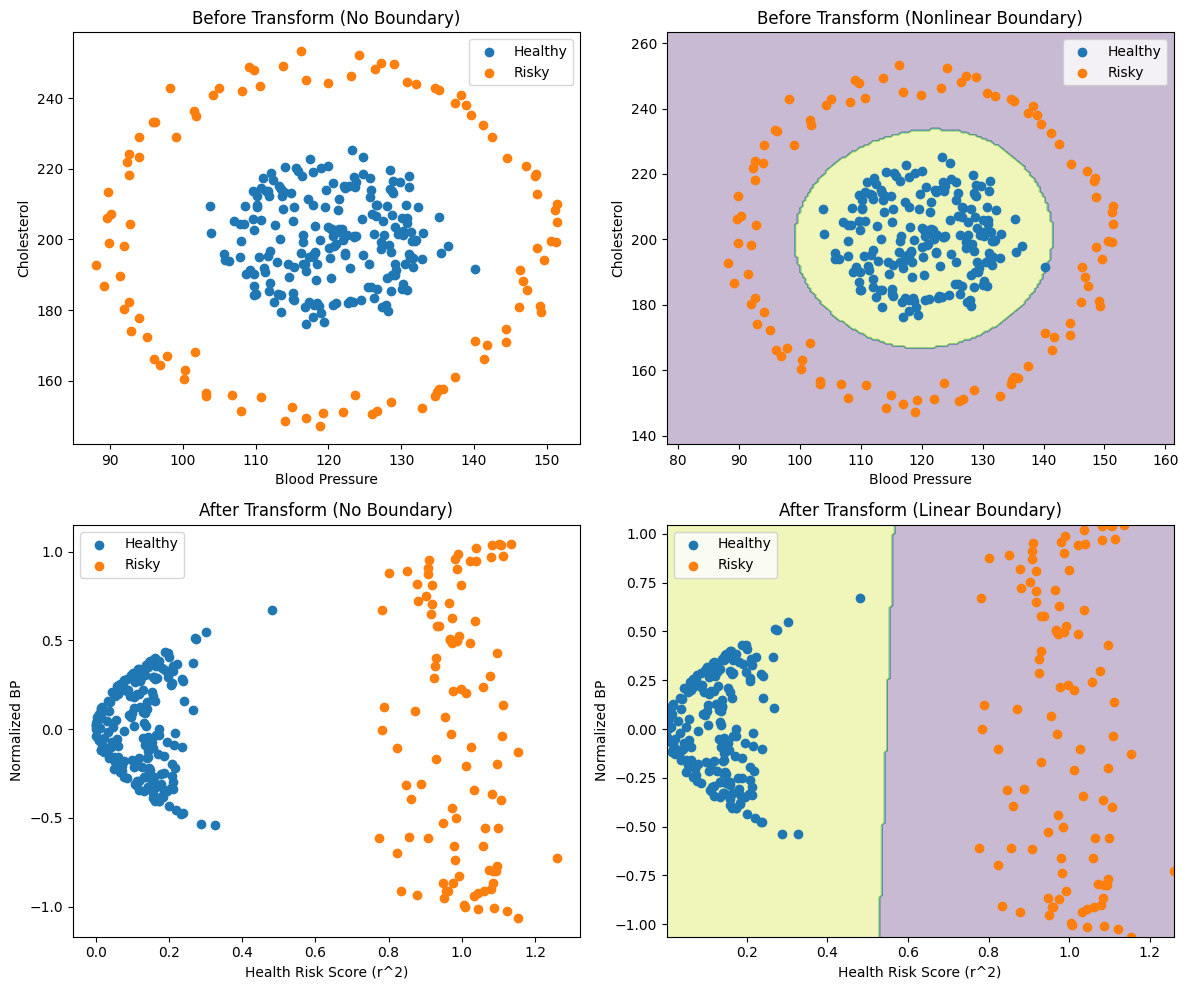

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.svm import SVC

# =====================
# 1️⃣ Generate Circle Data
# =====================
np.random.seed(32)
X, y = make_circles(n_samples=200, factor=0.4, noise=0.05, random_state=32)

# =====================
# ➕ Add HEALTHY center points
# =====================
n_center = 100
center_points = np.random.normal(loc=0.0, scale=0.2, size=(n_center, 2))

# label them as Healthy (1)
center_labels = np.ones(n_center)

# =====================
# Combine datasets
# =====================
X = np.vstack((X, center_points))
y = np.hstack((y, center_labels))

# =====================
# 2️⃣ Map to REAL units
# =====================
bp = 120 + 30 * X[:, 0]
chol = 200 + 50 * X[:, 1]

# =====================
# 3️⃣ Normalize
# =====================
x1 = (bp - 120) / 30
x2 = (chol - 200) / 50
X_norm = np.column_stack((x1, x2))

# =====================
# 4️⃣ Transform
# φ(x) = [r^2, x1]
# =====================
X_transformed = np.zeros_like(X_norm)
X_transformed[:, 0] = x1**2 + x2**2
X_transformed[:, 1] = x1

# =====================
# 5️⃣ Train Models
# =====================
# Nonlinear SVM (original space)
model_nonlinear = SVC(kernel='rbf')
model_nonlinear.fit(X_norm, y)

# Linear SVM (transformed space)
model_linear = SVC(kernel='linear')
model_linear.fit(X_transformed, y)

# =====================
# 6️⃣ Create Subplots
# =====================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# =====================
# 🔹 1. BEFORE — No Boundary
# =====================
ax = axes[0, 0]
for label_val in [1, 0]:
    ax.scatter(
        bp[y == label_val],
        chol[y == label_val],
        label='Healthy' if label_val == 1 else 'Risky'
    )

ax.set_title("Before Transform (No Boundary)")
ax.set_xlabel("Blood Pressure")
ax.set_ylabel("Cholesterol")
ax.legend()

# =====================
# 🔹 2. BEFORE — With Boundary (RBF)
# =====================
ax = axes[0, 1]

xx, yy = np.meshgrid(
    np.linspace(bp.min()-10, bp.max()+10, 200),
    np.linspace(chol.min()-10, chol.max()+10, 200)
)

gx1 = (xx - 120) / 30
gx2 = (yy - 200) / 50
grid = np.column_stack((gx1.ravel(), gx2.ravel()))

Z = model_nonlinear.predict(grid).reshape(xx.shape)

ax.contourf(xx, yy, Z, alpha=0.3)

for label_val in [1, 0]:
    ax.scatter(
        bp[y == label_val],
        chol[y == label_val],
        label='Healthy' if label_val == 1 else 'Risky'
    )

ax.set_title("Before Transform (Nonlinear Boundary)")
ax.set_xlabel("Blood Pressure")
ax.set_ylabel("Cholesterol")
ax.legend()

# =====================
# 🔹 3. AFTER — No Boundary
# =====================
ax = axes[1, 0]

for label_val in [1, 0]:
    ax.scatter(
        X_transformed[y == label_val, 0],
        X_transformed[y == label_val, 1],
        label='Healthy' if label_val == 1 else 'Risky'
    )

ax.set_title("After Transform (No Boundary)")
ax.set_xlabel("Health Risk Score (r^2)")
ax.set_ylabel("Normalized BP")
ax.legend()

# =====================
# 🔹 4. AFTER — With Boundary (Linear)
# =====================
ax = axes[1, 1]

# Grid in transformed space
z1, z2 = np.meshgrid(
    np.linspace(X_transformed[:,0].min(), X_transformed[:,0].max(), 200),
    np.linspace(X_transformed[:,1].min(), X_transformed[:,1].max(), 200)
)

grid_trans = np.column_stack((z1.ravel(), z2.ravel()))
Z_lin = model_linear.predict(grid_trans).reshape(z1.shape)

ax.contourf(z1, z2, Z_lin, alpha=0.3)

for label_val in [1, 0]:
    ax.scatter(
        X_transformed[y == label_val, 0],
        X_transformed[y == label_val, 1],
        label='Healthy' if label_val == 1 else 'Risky'
    )

ax.set_title("After Transform (Linear Boundary)")
ax.set_xlabel("Health Risk Score (r^2)")
ax.set_ylabel("Normalized BP")
ax.legend()

plt.tight_layout()
plt.show()

# 1. ambil parameter model: w dan b
- linear SVM punya decision function: w1 . z1 + w2 . z2 + b = 0. dengan z1 = r^2, z2 = x1. jadi, w = [w1,w2]
- `.coef_`: coef_ bentuknya (1, n_features).
- `.intercept_`: intercept_ bentuknya (1,)
- [0] untuk ambil baris pertama.

# 2. menentukan range plot
- `x_min` dan `x_max`: ambil range fitur pertama (r^2). tambah margin visual.
- `y_min` dan `y_max`: ambil range fitur kedua (x1). tambah margin visual.

# 3. membuat grid
- xx = koordinat z1
- yy = koordinat z2

# 4. prediksi seluruh space
- `Z_lin` = membuat peta klasifikasi di transfformed space
- `lt.contourf()`: visualisasi region kelas

# 5. plot data asli di transformed space
- `X_transformed[y == 1, 0]`: ambil semua titik healthy, kolom 0 = r^2
- `X_transformed[y == 0, 0]`: ambil semua titik risky, kolom 0 = r^2

# 6. decision boundary dan margin
- decision boundary: w·z + b = 0
- margin: w·z + b = +1 dan w·z + b = -1
- lebar margin = 2 / ||w||
- `y_boundary = (-w[0] * x_points - b) / w[1]`: mencari z2
- `if abs(w[1]) > 1e-6`: untuk menghindari division by zero. kalau w2≈0, w1.z1+b=0 --> z1=-b/w1.
- `plt.axvline()`: branch

# 7. support vectors
- memenuhi w.z + b = +-1
- `model.support_vectors_`: titik dengan αi > 0.

---
soft margin  
1/2 ||w||^2 + C Σ ξi  
ξi = slack variable = mengukur seberapa melanggar aturan  
ξ = 0 titik di luar/tepat marrgin (aman). 0 < ξ < 1 titik di dalam margin. ξ > 1 misclassified

---
KKT (Karush-Kuhn-Tucker) condition: kondisi optimal untuk problem optimisasi constrained. KKT menentukan mana titik yg jadi support vector dan mana yg bukan. 
- αi ≥ 0
- ξi ≥ 0
- αi [yi(w.xi + b) - 1 + ξi] = 0

αi = 0, bukan sv dan jauh dari margin. 0<αi<C, sv dan tepat di margin (ξi=0). αi = C, sv, di dalam margin atau misclassified.  

---
ξi muncul di formulasi primal (original space).  
αi = lagrange multiplier. muncul di formulasi dual (kernel friendly).  
makna αi = bobot kontribusi titik i dalam membentuk hyperplane.  
C = trade off parameter. C kecil toleransi error tinggi, C besar toleransi error rendah.  

intinya:  
- ξi = berapa kamu melanggar aturan
- αi = seberapa keras kamu menarik boundary
- C = seberapa ketat aturan ditegakkan

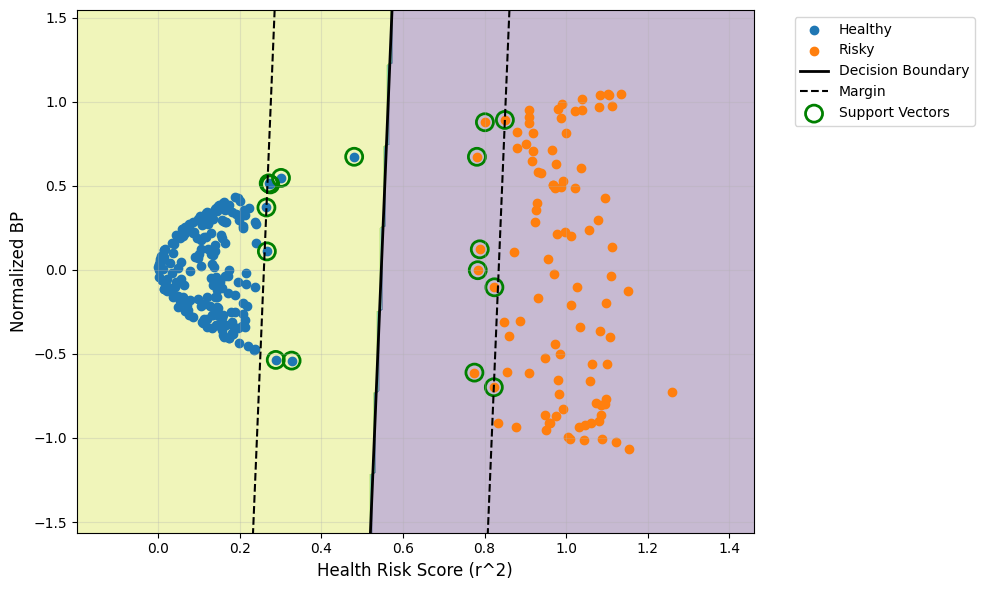

In [9]:
#1
w = model_linear.coef_[0]
b = model_linear.intercept_[0]

plt.figure(figsize=(10, 6))

#2
x_min = np.min(X_transformed[:, 0]) - 0.2
x_max = np.max(X_transformed[:, 0]) + 0.2
y_min = np.min(X_transformed[:, 1]) - 0.5
y_max = np.max(X_transformed[:, 1]) + 0.5

#3
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)
grid_trans = np.column_stack((xx.ravel(), yy.ravel()))

#4
Z_lin = model_linear.predict(grid_trans).reshape(xx.shape)

plt.contourf(xx, yy, Z_lin, alpha=0.3)

#5
plt.scatter(X_transformed[y == 1, 0], X_transformed[y == 1, 1], color='#1f77b4', label='Healthy')
plt.scatter(X_transformed[y == 0, 0], X_transformed[y == 0, 1], color='#ff7f0e', label='Risky')

#6
x_points = np.linspace(x_min, x_max, 100)

if abs(w[1]) > 1e-6:
    # Garis normal
    y_boundary = (-w[0] * x_points - b) / w[1]
    y_margin_plus = (-w[0] * x_points - b + 1) / w[1]
    y_margin_minus = (-w[0] * x_points - b - 1) / w[1]

    plt.plot(x_points, y_boundary, 'k-', linewidth=2, label='Decision Boundary')
    plt.plot(x_points, y_margin_plus, 'k--', linewidth=1.5, label='Margin')
    plt.plot(x_points, y_margin_minus, 'k--', linewidth=1.5)
else:
    # Garis vertikal
    x_boundary = -b / w[0]
    x_margin_plus = -(b - 1) / w[0]
    x_margin_minus = -(b + 1) / w[0]

    plt.axvline(x_boundary, color='k', linewidth=2, label='Decision Boundary')
    plt.axvline(x_margin_plus, color='k', linestyle='--', linewidth=1.5, label='Margin')
    plt.axvline(x_margin_minus, color='k', linestyle='--', linewidth=1.5)

#7
support_vectors = model_linear.support_vectors_
plt.scatter(support_vectors[:, 0], support_vectors[:, 1], s=150, 
            facecolors='none', edgecolors='green', linewidth=2, 
            label='Support Vectors')

plt.xlabel("Health Risk Score (r^2)", fontsize=12)
plt.ylabel("Normalized BP", fontsize=12)
plt.ylim(y_min, y_max)
plt.xlim(x_min, x_max)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

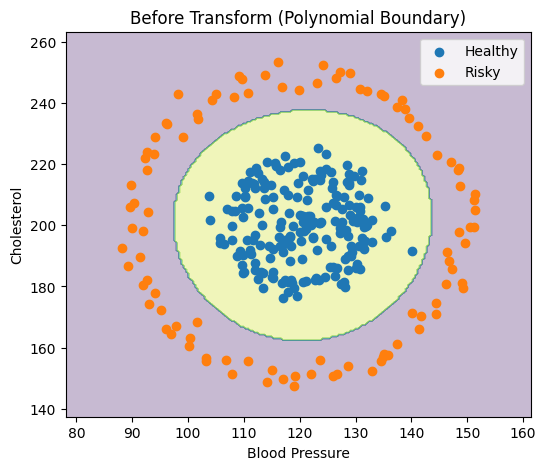

In [6]:
# implicit: polynomial kernel SVM
model_poly = SVC(kernel='poly', degree=3, coef0=1, C=1)
model_poly.fit(X_norm, y)

# =====================
# BEFORE — With Boundary (Polynomial)
# =====================
fig2, ax = plt.subplots(figsize=(6, 5))

# grid sama seperti sebelumnya
xx, yy = np.meshgrid(
    np.linspace(bp.min()-10, bp.max()+10, 200),
    np.linspace(chol.min()-10, chol.max()+10, 200)
)

# normalize grid
gx1 = (xx - 120) / 30
gx2 = (yy - 200) / 50
grid = np.column_stack((gx1.ravel(), gx2.ravel()))

# predict pakai polynomial
Z_poly = model_poly.predict(grid).reshape(xx.shape)

# plot decision boundary
ax.contourf(xx, yy, Z_poly, alpha=0.3)

# plot data
for label_val in [1, 0]:
    ax.scatter(
        bp[y == label_val],
        chol[y == label_val],
        label='Healthy' if label_val == 1 else 'Risky'
    )

ax.set_title("Before Transform (Polynomial Boundary)")
ax.set_xlabel("Blood Pressure")
ax.set_ylabel("Cholesterol")
ax.legend()

plt.show()